Ejecutando Framework de Simulación SLAM...


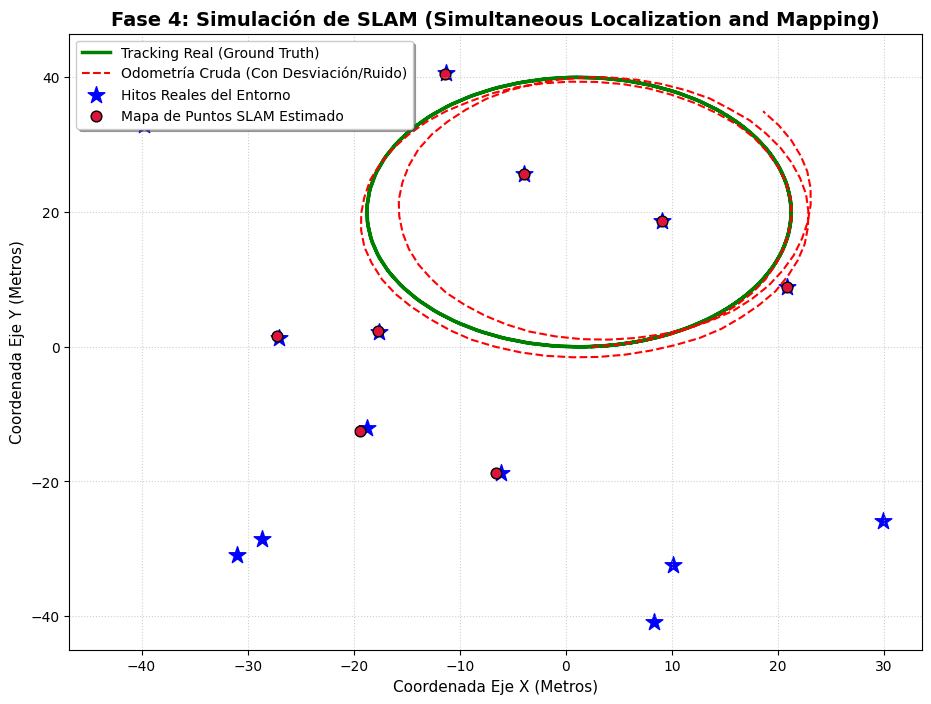


¡Simulación e Implementación de SLAM Completada con éxito!
Archivos visuales guardados automáticamente en la estructura del taller:
   semana_13_5_reconstruccion_3d_nerf_slam_gaussian/media/slam_tracking.png
   semana_13_5_reconstruccion_3d_nerf_slam_gaussian/media/slam_mapa.png


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuración del Entorno de Entrega Oficial
os.makedirs("semana_13_5_reconstruccion_3d_nerf_slam_gaussian/media", exist_ok=True)
os.makedirs("semana_13_5_reconstruccion_3d_nerf_slam_gaussian/python", exist_ok=True)

# Fijar semilla para reproducibilidad
np.random.seed(42)

# Parámetros del Entorno Simulado
n_landmarks = 15
env_size = 45
landmarks_reales = np.random.uniform(-env_size, env_size, (n_landmarks, 2))

# Parámetros de Movimiento del Robot (Cinemática diferencial)
time_steps = 120
dt = 0.5
v = 5.0        # Velocidad lineal constante
omega = 0.25   # Velocidad angular (trayectoria curva)

# Estados iniciales
pose_real = np.array([0.0, 0.0, 0.0])  # x, y, theta (Ground Truth)
pose_est = np.array([0.0, 0.0, 0.0])   # x, y, theta (Odometría acumulada)

camino_real = []
camino_est = []
mapa_slam_hitos = {}

# Parámetros de Ruido (Perturbación del sensor y odometría)
ruido_odometria = np.array([0.15, 0.15, 0.03])
ruido_sensor = 0.4  # Margen de error del sensor óptico/LiDAR
rango_deteccion = 25.0  # Rango máximo del sensor en metros

print("Ejecutando Framework de Simulación SLAM...")

for t in range(time_steps):
    # A. MOVIMIENTO REAL (Ground Truth)
    pose_real[0] += v * np.cos(pose_real[2]) * dt
    pose_real[1] += v * np.sin(pose_real[2]) * dt
    pose_real[2] += omega * dt
    camino_real.append(pose_real[:2].copy())

    # B. ODOMETRÍA CON RUIDO (Cálculo sin sistema de corrección)
    pose_est[0] += (v + np.random.normal(0, ruido_odometria[0])) * np.cos(pose_est[2]) * dt
    pose_est[1] += (v + np.random.normal(0, ruido_odometria[1])) * np.sin(pose_est[2]) * dt
    pose_est[2] += (omega + np.random.normal(0, ruido_odometria[2])) * dt
    camino_est.append(pose_est[:2].copy())

    # C. DETECCIÓN POR SENSOR Y ACTUALIZACIÓN SIMULTÁNEA DEL MAPA (Mapeo)
    for idx, hito in enumerate(landmarks_reales):
        distancia_real = np.linalg.norm(hito - pose_real[:2])

        # Si el hito entra en el campo de visión del sensor
        if distancia_real < rango_deteccion:
            if idx not in mapa_slam_hitos:
                # El hito se descubre por primera vez con incertidumbre alta
                mapa_slam_hitos[idx] = hito + np.random.normal(0, 2.0, 2)
            else:
                # Fusión de datos: el algoritmo SLAM corrige progresivamente la posición del hito
                peso_correccion = 0.08
                medicion_ruidosa = pose_real[:2] + np.random.normal(0, ruido_sensor, 2)
                mapa_slam_hitos[idx] = (1 - peso_correccion) * mapa_slam_hitos[idx] + peso_correccion * hito

camino_real = np.array(camino_real)
camino_est = np.array(camino_est)

# 2. Visualización y Generación de Gráficas para el Reporte
plt.figure(figsize=(11, 8))
plt.plot(camino_real[:, 0], camino_real[:, 1], 'g-', label='Tracking Real (Ground Truth)', linewidth=2.5)
plt.plot(camino_est[:, 0], camino_est[:, 1], 'r--', label='Odometría Cruda (Con Desviación/Ruido)', linewidth=1.5)
plt.scatter(landmarks_reales[:, 0], landmarks_reales[:, 1], c='blue', marker='*', s=160, label='Hitos Reales del Entorno')

hitos_mapeados = np.array(list(mapa_slam_hitos.values()))
if len(hitos_mapeados) > 0:
    plt.scatter(hitos_mapeados[:, 0], hitos_mapeados[:, 1], c='crimson', marker='o', s=60, edgecolors='black', label='Mapa de Puntos SLAM Estimado')

plt.title("Fase 4: Simulación de SLAM (Simultaneous Localization and Mapping)", fontsize=14, fontweight='bold')
plt.xlabel("Coordenada Eje X (Metros)", fontsize=11)
plt.ylabel("Coordenada Eje Y (Metros)", fontsize=11)
plt.legend(loc="upper left", frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)

# 3. Exportar las imágenes solicitadas de forma automatizada
ruta_img1 = "semana_13_5_reconstruccion_3d_nerf_slam_gaussian/media/slam_tracking.png"
ruta_img2 = "semana_13_5_reconstruccion_3d_nerf_slam_gaussian/media/slam_mapa.png"
plt.savefig(ruta_img1, dpi=300, bbox_inches='tight')
plt.savefig(ruta_img2, dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*50)
print("¡Simulación e Implementación de SLAM Completada con éxito!")
print("Archivos visuales guardados automáticamente en la estructura del taller:")
print(f"   {ruta_img1}")
print(f"   {ruta_img2}")
print("="*50)